# TASK1: EDA on Retail Sales Data

1.Load Dataset & Initial Inspection

In [12]:
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns

df = pd.read_csv("ecommerce_dataset_10000.csv")

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10000, 20)

Dtypes:
 customer_id       object
first_name        object
last_name         object
gender            object
age_group         object
signup_date       object
country           object
product_id        object
product_name      object
category          object
quantity           int64
unit_price         int64
order_id          object
order_date        object
order_status      object
payment_method    object
rating             int64
review_text       object
review_id         object
review_date       object
dtype: object

Missing values:
 customer_id       0
first_name        0
last_name         0
gender            0
age_group         0
signup_date       0
country           0
product_id        0
product_name      0
category          0
quantity          0
unit_price        0
order_id          0
order_date        0
order_status      0
payment_method    0
rating            0
review_text       0
review_id         0
review_date       0
dtype: int64

Duplicate rows: 0


2.Descriptive Statistics

In [13]:
df['revenue'] = df['quantity'] * df['unit_price']
num_cols = ['quantity', 'unit_price', 'revenue', 'rating']

print(df[num_cols].describe())
print("\nMode:\n", df[num_cols].mode().iloc[0])

           quantity    unit_price       revenue        rating
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       3.000800    246.647200    745.076300      2.993100
std        1.416474    282.605391   1012.443334      1.410621
min        1.000000     25.000000     25.000000      1.000000
25%        2.000000     80.000000    198.000000      2.000000
50%        3.000000    129.000000    398.000000      3.000000
75%        4.000000    229.000000    796.000000      4.000000
max        5.000000    999.000000   4995.000000      5.000000

Mode:
 quantity       4
unit_price    59
revenue       59
rating         3
Name: 0, dtype: int64


3. Time Series Analysis

* Best Month: Aug 2024 → $247,751
* Worst Month: Aug 2022 → $59,094


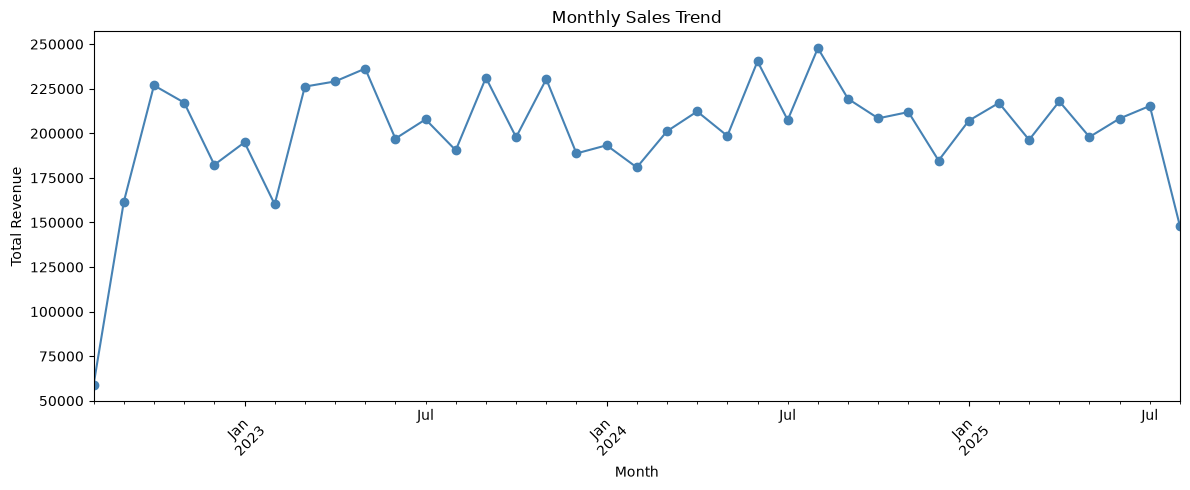

In [14]:
# Monthly Analysis
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')
df['order_quarter'] = df['order_date'].dt.to_period('Q')

monthly_sales = df.groupby('order_month')['revenue'].sum()
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
print(f"* Best Month: {best_month.strftime('%b %Y')} \u2192 ${monthly_sales.max():,.0f}")
print(f"* Worst Month: {worst_month.strftime('%b %Y')} \u2192 ${monthly_sales.min():,.0f}")

plt.figure(figsize=(12 ,5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Monthly_Sales.png', dpi=150)
plt.show()

* Best Quarter: Q3 2024 → $674,535


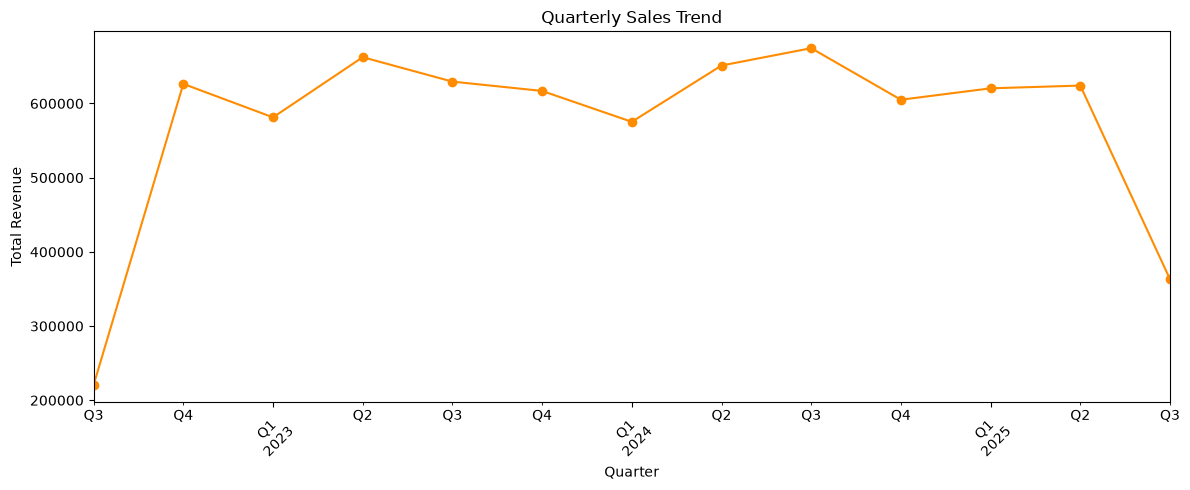

In [15]:
# Quarterly Analysis
quarterly_sales = df.groupby('order_quarter')['revenue'].sum()
best_quarter = quarterly_sales.idxmax()
print(f"* Best Quarter: Q{best_quarter.quarter} {best_quarter.year} \u2192 ${quarterly_sales.max():,.0f}")

plt.figure(figsize=(12,5))
quarterly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Quarterly_Sales.png', dpi=150)
plt.show()

4. Customer Demographics - Age group & Gender

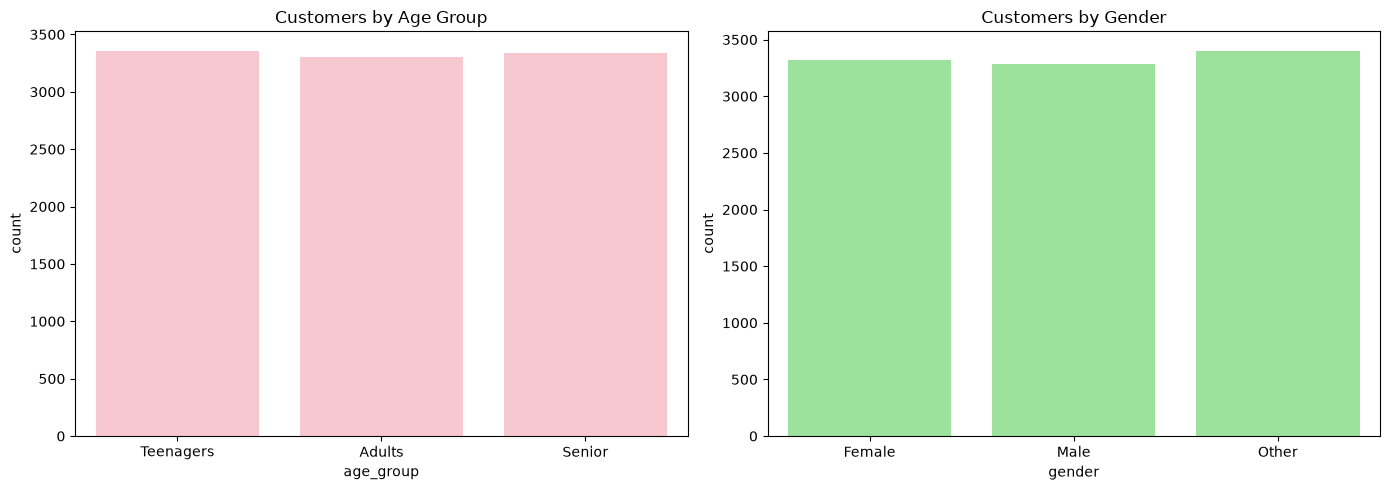

--- Orders by Age Group ---
Age Group  Orders
Teenagers    3359
   Senior    3342
   Adults    3299

--- Orders by Gender ---
Gender  Orders
 Other    3403
Female    3316
  Male    3281


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='age_group', ax=axes[0], color='pink')
axes[0].set_title('Customers by Age Group')
sns.countplot(data=df, x='gender', ax=axes[1], color='lightgreen')
axes[1].set_title('Customers by Gender')
plt.tight_layout()
plt.savefig('demographics.png', dpi=150)
plt.show()

# Orders by Age Group and Gender
age_table = df['age_group'].value_counts().reset_index()
age_table.columns = ['Age Group', 'Orders']

gender_table = df['gender'].value_counts().reset_index()
gender_table.columns = ['Gender', 'Orders']

print("--- Orders by Age Group ---")
print(age_table.to_string(index=False))

print("\n--- Orders by Gender ---")
print(gender_table.to_string(index=False))

5. Product Analysis

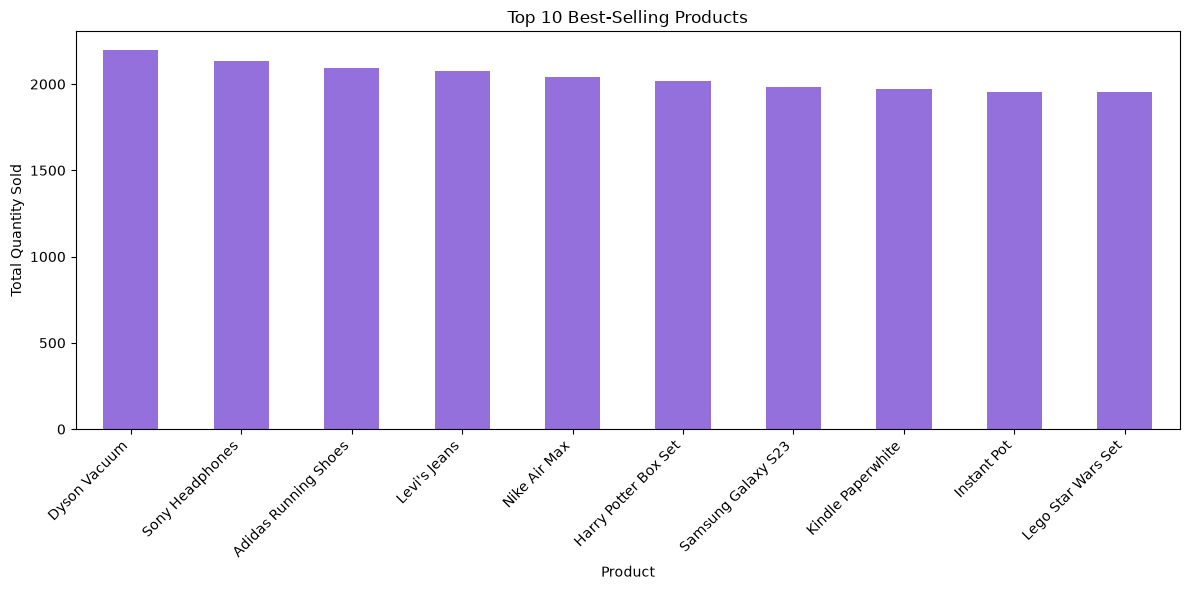

In [17]:
# Top 10 Products 
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('Top10_products.png', dpi=150); plt.show()

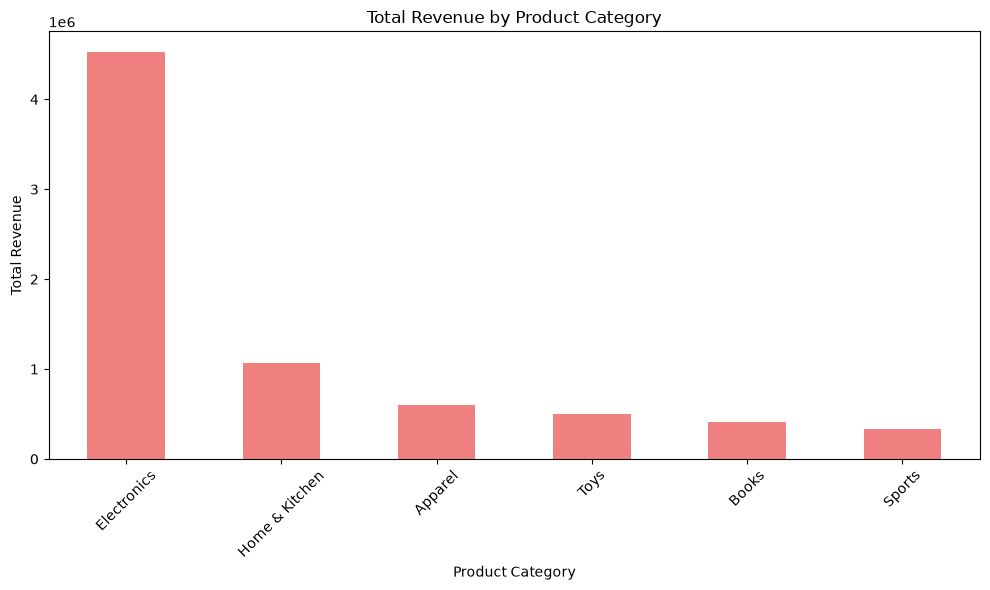

In [18]:
# Revenue by Product Category
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
category_revenue.plot(kind='bar', color='lightcoral')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Revenue_by_Category.png', dpi=150)
plt.show()

6. Correlation Heatmap

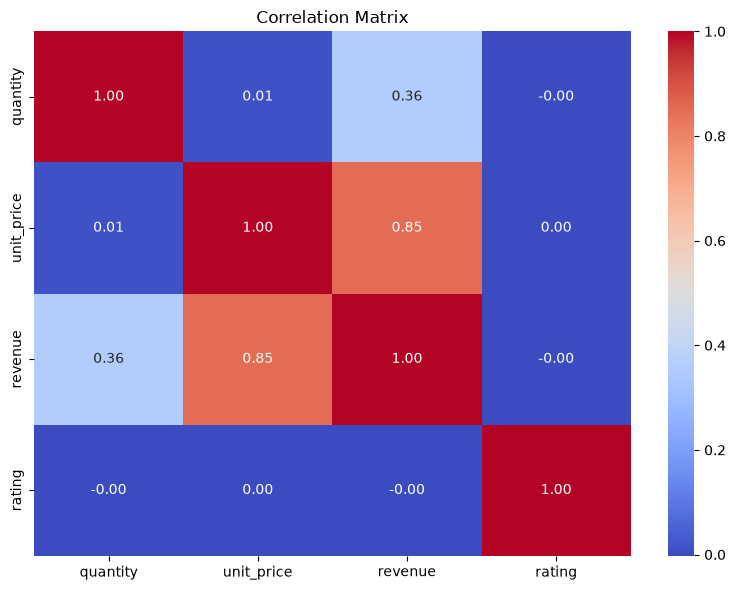

In [19]:
corr = df[['quantity','unit_price','revenue','rating']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('Correlation_Matrix.png', dpi=150)
plt.show()

7. Extra Visualization — Order Status by Payment Method

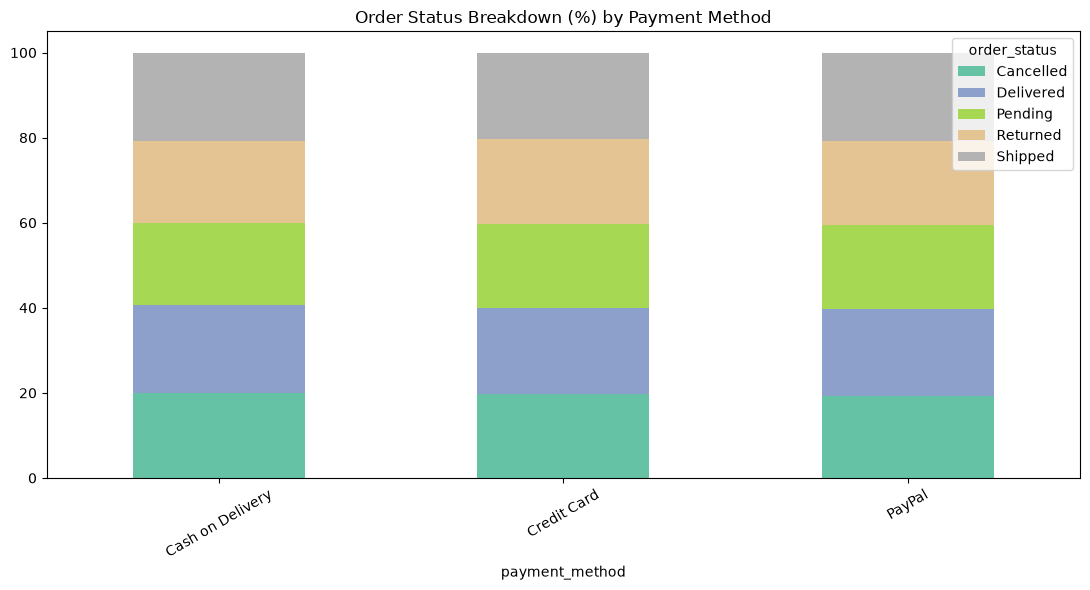

In [20]:
status_payment = pd.crosstab(df['payment_method'], df['order_status'], normalize='index') * 100
status_payment.plot(kind='bar', stacked=True, figsize=(11,6), colormap='Set2')
plt.title('Order Status Breakdown (%) by Payment Method')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Order_Status_Breakdown.png', dpi=150)
plt.show()

# Observations

{Monthly Sales Chart}:  Monthly sales ranges between $180k-$248k which shows that the sales are stable and the best sales month is August 2024 ($247,751). The seasonal recursion (e.g: holiday spikes) is not visible and the worst year of sales is August 2022 ($59,094).

{Quarterly Sales Chart}:  The peaked quarterly sales revenue is in Q3 2024 ($674,535) and the best part is it remain consistently above $575k per quarter since 2022, which tells a stable business growth.

{Customer Demograph Chart}:  Orders are near-evenly distributed across age groups [Teenagers 33.6%, Senior 33.4%, Adults 33.0%] and genders [Other 34.0%, Female 33.2%, Male 32.8%].

{Top 10 Products Chart}:  The Dyson Vacuum leads unit sales (2,196 units), closely followed by Sony Headphones and Adidas Running Shoes.

{Revenue by Category}:  Electronics generates $4.53M in revenue — over 4x the next-highest category, Home & Kitchen ($1.07M) — despite not dominating unit sales.

{Correlation Heatmap}:  Unit price and revenue show strong positive correlation (0.85), as expected. Notably, customer rating shows near-zero correlation (~0.00) with price, quantity, and revenue.

{Order Status by Payment Method}:  Order status distribution (Cancelled, Delivered, Pending, Returned, Shipped) is nearly identical across all three payment methods (~19–21% each).

# Conclusion & Business Recommendations

This analysis of 10,000 retail transactions reveals a stable, demographically diverse business with a clear revenue concentration in Electronics.

1. Prioritize Electronics category investment:
Electronics drives 4x the revenue of the next-best category despite comparable unit sales to other top products. Reallocating marketing budget and negotiating better supplier terms for Electronics (particularly the Dyson Vacuum and Sony Headphones) could compound an already-dominant revenue stream.

2. Investigate and replicate Q3 2024 performance drivers:
Q3 2024 was the strongest quarter on record ($674,535). A root-cause review (promotions run, marketing spend, seasonal demand) should be conducted so successful tactics can be systematically repeated in future quarters rather than left to chance.

3. Consolidate marketing spend into a single cross-segment strategy:
Since order volume is nearly identical across all age groups and genders, resources currently allocated to segment specific campaigns could be redirected toward broader reach channels, improving marketing ROI without sacrificing coverage.

4. Launch a post-delivery customer experience audit:
Since satisfaction (rating) is uncorrelated with price or order size, the business should investigate operational touchpoints — delivery speed, packaging, support responsiveness — as the true levers of customer satisfaction, rather than assuming higher-value customers are automatically more satisfied.

5. Do not restrict Cash on Delivery availability:
Since COD shows no elevated cancellation or return rate compared to digital payments, any plans to limit COD to reduce fulfillment risk are not supported by the data and could unnecessarily reduce accessibility for COD-preferring customers.
